# Cohesive Fracture: Nitsche's Method

!!! info

    This example uses `PETSc` to solver the nonlinear problem. Please ensure that `petsc4py` is installed to run this example. 


In this notebook, we simulate quasi-static crack propagation in a 3D pre-cracked specimen under Mode I loading using **Nitsche's method** for the interface. The domain consists of two hexahedral mesh blocks separated by a cohesive interface at $y=0$.

The key ingredients are:

- A **bulk elastic body** discretized with `Hexahedron8` elements
- A **cohesive interface** at $y=0$ for $x \geq L_\text{crack}$, discretized with `Quad4` manifold elements
- A **Nitsche-based traction–separation law** that transitions from a tied constraint to a cohesive zone model upon fracture initiation
- Displacement-controlled quasi-static loading in the $y$-direction with a PETSc SNES nonlinear solver

In [ ]:
import os
from typing import Callable

import gmsh
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import meshio
import numpy as np
import pyvista as pv
from jax import Array
from jax_autovmap import autovmap
from petsc4py import PETSc
from tatva.sparse._extraction import _create_sparse_structure

from tatva import Mesh, Operator, element, sparse

jax.config.update("jax_enable_x64", True)

## Mesh generation

We generate a 3D mesh consisting of two hexahedral blocks separated by a fracture interface. The geometry is a rectangular box of dimensions $L_x \times L_y \times L_z$, split along the midplane $y=0$ into a top block ($y > 0$) and a bottom block ($y < 0$, mirrored). The cohesive interface occupies the region $x \geq L_\text{crack}$, $y=0$, while the pre-crack region ($x < L_\text{crack}$) is traction-free.

An unstructured hexahedral mesh is generated using Gmsh: tetrahedral elements are first created with a Delaunay algorithm using graded mesh sizes (fine near the crack tip, coarse far away), then subdivided into hexahedra via Gmsh's subdivision algorithm.

In [ ]:
# [collapse: code] Function to generate unstructured hex mesh with Gmsh and extract interface quads

def generate_unstructured_hex_fracture_3d(
    length: float,
    height: float,
    thickness: float,
    crack_tip_x: float,
    mesh_size_tip: float,
    mesh_size_far: float,
    work_dir: str = "../meshes",
):
    """
    Generates a 3D fracture assembly with an Unstructured HEXAHEDRAL mesh.

    Strategy:
    1. Define geometry with split at crack tip.
    2. Generate unstructured Tetrahedrons based on sizing fields.
    3. Use Gmsh Subdivision (Algo=2) to split Tets into Hexes.

    Result:
    - Volume: Hexahedrons
    - Interface: Quads
    """
    if not os.path.exists(work_dir):
        os.makedirs(work_dir)

    filename = os.path.join(work_dir, "temp_half_block_hex.msh")

    gmsh.initialize()
    gmsh.model.add("half_block_hex")

    h_half = height / 2.0

    # --- 1. Define Geometry (Identical to previous logic) ---

    # Points: Bottom Face (y=0)
    p1 = gmsh.model.geo.addPoint(0, 0, 0, mesh_size_far)
    p4 = gmsh.model.geo.addPoint(0, 0, thickness, mesh_size_far)
    # x=crack_tip (Refined)
    pt1 = gmsh.model.geo.addPoint(crack_tip_x, 0, 0, mesh_size_tip)
    pt2 = gmsh.model.geo.addPoint(crack_tip_x, 0, thickness, mesh_size_tip)
    # x=L
    p2 = gmsh.model.geo.addPoint(length, 0, 0, mesh_size_tip)
    p3 = gmsh.model.geo.addPoint(length, 0, thickness, mesh_size_tip)

    # Points: Top Face (y=h/2)
    p5 = gmsh.model.geo.addPoint(0, h_half, 0, mesh_size_far)
    p8 = gmsh.model.geo.addPoint(0, h_half, thickness, mesh_size_far)
    # x=crack_tip (Refined)
    pt3 = gmsh.model.geo.addPoint(crack_tip_x, h_half, 0, mesh_size_far)
    pt4 = gmsh.model.geo.addPoint(crack_tip_x, h_half, thickness, mesh_size_far)
    # x=L
    p6 = gmsh.model.geo.addPoint(length, h_half, 0, mesh_size_far)
    p7 = gmsh.model.geo.addPoint(length, h_half, thickness, mesh_size_far)

    # Lines: Bottom
    l1 = gmsh.model.geo.addLine(p1, pt1)
    l2 = gmsh.model.geo.addLine(pt1, p2)
    l_right_b = gmsh.model.geo.addLine(p2, p3)
    l3 = gmsh.model.geo.addLine(p3, pt2)
    l4 = gmsh.model.geo.addLine(pt2, p4)
    l_left_b = gmsh.model.geo.addLine(p4, p1)
    l_crack_b = gmsh.model.geo.addLine(pt1, pt2)  # Crack front

    # Lines: Top
    l5 = gmsh.model.geo.addLine(p5, pt3)
    l6 = gmsh.model.geo.addLine(pt3, p6)
    l_right_t = gmsh.model.geo.addLine(p6, p7)
    l7 = gmsh.model.geo.addLine(p7, pt4)
    l8 = gmsh.model.geo.addLine(pt4, p8)
    l_left_t = gmsh.model.geo.addLine(p8, p5)
    l_crack_t = gmsh.model.geo.addLine(pt3, pt4)

    # Lines: Vertical
    v1 = gmsh.model.geo.addLine(p1, p5)
    v_tip1 = gmsh.model.geo.addLine(pt1, pt3)
    v2 = gmsh.model.geo.addLine(p2, p6)
    v3 = gmsh.model.geo.addLine(p3, p7)
    v_tip2 = gmsh.model.geo.addLine(pt2, pt4)
    v4 = gmsh.model.geo.addLine(p4, p8)

    # Surfaces (Pre/Post Crack Split)
    loop_if_1 = gmsh.model.geo.addCurveLoop([l1, l_crack_b, l4, l_left_b])
    s_if_1 = gmsh.model.geo.addPlaneSurface([loop_if_1])

    loop_if_2 = gmsh.model.geo.addCurveLoop([l2, l_right_b, l3, -l_crack_b])
    s_if_2 = gmsh.model.geo.addPlaneSurface([loop_if_2])

    loop_top_1 = gmsh.model.geo.addCurveLoop([l5, l_crack_t, l8, l_left_t])
    s_top_1 = gmsh.model.geo.addPlaneSurface([loop_top_1])

    loop_top_2 = gmsh.model.geo.addCurveLoop([l6, l_right_t, l7, -l_crack_t])
    s_top_2 = gmsh.model.geo.addPlaneSurface([loop_top_2])

    # Sides
    s_left = gmsh.model.geo.addPlaneSurface(
        [gmsh.model.geo.addCurveLoop([l_left_b, v1, -l_left_t, -v4])]
    )
    s_right = gmsh.model.geo.addPlaneSurface(
        [gmsh.model.geo.addCurveLoop([l_right_b, v3, -l_right_t, -v2])]
    )
    s_front_1 = gmsh.model.geo.addPlaneSurface(
        [gmsh.model.geo.addCurveLoop([l1, v_tip1, -l5, -v1])]
    )
    s_front_2 = gmsh.model.geo.addPlaneSurface(
        [gmsh.model.geo.addCurveLoop([l2, v2, -l6, -v_tip1])]
    )
    s_back_1 = gmsh.model.geo.addPlaneSurface(
        [gmsh.model.geo.addCurveLoop([l4, v4, -l8, -v_tip2])]
    )
    s_back_2 = gmsh.model.geo.addPlaneSurface(
        [gmsh.model.geo.addCurveLoop([l3, v_tip2, -l7, -v3])]
    )
    s_mid = gmsh.model.geo.addPlaneSurface(
        [gmsh.model.geo.addCurveLoop([l_crack_b, v_tip2, -l_crack_t, -v_tip1])]
    )

    # Volumes
    sl1 = gmsh.model.geo.addSurfaceLoop(
        [s_if_1, s_top_1, s_left, s_front_1, s_back_1, s_mid]
    )
    vol1 = gmsh.model.geo.addVolume([sl1])
    sl2 = gmsh.model.geo.addSurfaceLoop(
        [s_if_2, s_top_2, s_right, s_front_2, s_back_2, s_mid]
    )
    vol2 = gmsh.model.geo.addVolume([sl2])

    gmsh.model.geo.synchronize()

    # --- Physical Groups ---
    gmsh.model.addPhysicalGroup(2, [s_if_1, s_if_2], 1, name="interface_surface")
    gmsh.model.addPhysicalGroup(3, [vol1, vol2], 2, name="top_domain")

    # --- CRITICAL: Switch to Hexahedron Generation ---
    # 1. We keep Algorithm3D as default (Delaunay/Tet), but...
    # 2. We enable Subdivision Algorithm = 2 (All Hexahedra)
    #    This splits every Tet into 4 Hexes, ensuring unstructured grading
    #    while returning pure Hex topology.
    gmsh.option.setNumber("Mesh.SubdivisionAlgorithm", 2)

    # Optional: Increase element order to 1 (Linear Hex) or 2 (Quadratic Hex)
    # Default is 1.

    gmsh.model.mesh.generate(3)
    gmsh.write(filename)
    gmsh.finalize()

    # --- 2. Read and Mirror ---
    _m = meshio.read(filename)
    if os.path.exists(filename):
        os.remove(filename)

    points_top = _m.points  # (N, 3)

    # Change: Read HEXAHEDRONS instead of Tetrahedrons
    hex_top = _m.cells_dict["hexahedron"]

    # Change: Read QUADS for interface
    interface_surf_idx = _m.cell_sets_dict["interface_surface"]["quad"]
    all_interface_quads_top = _m.cells_dict["quad"][interface_surf_idx]

    # Mirror to create Bottom
    points_bottom = points_top.copy()
    points_bottom[:, 1] *= -1  # Flip Y
    points_bottom[:, 1] -= 1e-10

    N_half = len(points_top)

    # Mirror Hexes & Fix Winding
    # Hex Node Order: 0,1,2,3 (base), 4,5,6,7 (top)
    # When flipping Y, we must swap nodes to restore positive determinant.
    # Swap 1 <-> 3 and 5 <-> 7
    hex_bottom = hex_top + N_half

    # Swapping columns for proper orientation:
    # 1 (idx 1) <-> 3 (idx 3)
    # 5 (idx 5) <-> 7 (idx 7)
    hex_bottom[:, [1, 3]] = hex_bottom[:, [3, 1]]
    hex_bottom[:, [5, 7]] = hex_bottom[:, [7, 5]]

    # Global Arrays
    coords = np.vstack([points_top, points_bottom])
    elements = np.vstack([hex_top, hex_bottom])

    # --- 3. Robust Interface Extraction (QUADS) ---

    # Calculate Centroids of QUADS
    quad_coords = points_top[all_interface_quads_top]
    centroids_x = np.mean(quad_coords[:, :, 0], axis=1)

    # Filter based on crack tip location
    active_mask = centroids_x >= (crack_tip_x - 1e-9)

    active_quads_top = all_interface_quads_top[active_mask]
    active_quads_bottom = active_quads_top + N_half

    # Compacting
    unique_nodes_bot, inverse_indices = jnp.unique(
        active_quads_bottom, return_inverse=True
    )

    interface_coords = coords[unique_nodes_bot]
    interface_connectivity = inverse_indices.reshape(active_quads_bottom.shape)

    interface_mesh = Mesh(interface_coords, interface_connectivity)

    bottom_interface_nodes = unique_nodes_bot
    top_interface_nodes = bottom_interface_nodes - N_half
    mesh = Mesh(coords, elements)

    # Note: Returns active_quads instead of active_tris
    return (
        mesh,
        interface_mesh,
        top_interface_nodes,
        bottom_interface_nodes,
        active_quads_top,
        active_quads_bottom,
    )

## Interface element: `Quad4Manifold`

To integrate quantities over the 2D cohesive interface embedded in 3D space, we define a `Quad4Manifold` element that extends the standard `Quad4` to handle **surface integration on a manifold**. The surface Jacobian is:

$$
J_\text{surf} = \sqrt{\det(\boldsymbol{J}\boldsymbol{J}^T)}
$$

where $\boldsymbol{J} = \partial \boldsymbol{x} / \partial \boldsymbol{\xi}$ is the $(2 \times 3)$ Jacobian mapping from reference coordinates $\boldsymbol{\xi} \in \mathbb{R}^2$ to physical coordinates $\boldsymbol{x} \in \mathbb{R}^3$. The pseudoinverse $\boldsymbol{J}^+ = \boldsymbol{J}^T(\boldsymbol{J}\boldsymbol{J}^T)^{-1}$ is used to compute surface gradients correctly.

In [3]:
@jax.jit
def safe_sqrt(x):
    return jnp.sqrt(jnp.where(x > 0.0, x, 0.0))


class Quad4Manifold(element.Quad4):
    def get_jacobian(self, xi: Array, nodal_coords: Array) -> tuple[Array, Array]:
        dNdr = self.shape_function_derivative(xi)
        J = dNdr @ nodal_coords
        detJ = safe_sqrt(jnp.linalg.det(J @ J.T))
        return J, detJ

    def gradient(self, xi: Array, nodal_values: Array, nodal_coords: Array) -> Array:
        dNdr = self.shape_function_derivative(xi)  # shape (2, 3)
        J, _ = self.get_jacobian(xi, nodal_coords)  # shape (2, 3)

        G_inv = jnp.linalg.inv(J @ J.T)  # shape (2, 2)
        J_plus = J.T @ G_inv  # shape (3, 2)

        dudxi = dNdr @ nodal_values  # shape (2, n_values)
        return J_plus @ dudxi  # shape (3, n_values)

## Defining the bulk strain energy density

The linear elastic strain energy density at a point is:

$$
\psi_\text{bulk}(\nabla \boldsymbol{u}) = \frac{1}{2}\,\boldsymbol{\sigma} : \boldsymbol{\varepsilon}
$$

where the stress and strain tensors are:

$$
\boldsymbol{\sigma} = \lambda\,\mathrm{tr}(\boldsymbol{\varepsilon})\boldsymbol{I} + 2\mu\,\boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon} = \frac{1}{2}(\nabla \boldsymbol{u} + \nabla \boldsymbol{u}^T)
$$

The total bulk elastic energy integrated over the domain $\Omega$ is:

$$
\Psi_\text{bulk}(\boldsymbol{u}) = \int_\Omega \psi_\text{bulk}(\nabla \boldsymbol{u})\,\mathrm{d}V
$$

In [4]:
@autovmap(grad_u=2)
def compute_strain(grad_u):
    return 0.5 * (grad_u + grad_u.T)


@autovmap(eps=2, mu=0, lmbda=0)
def compute_stress(eps, mu, lmbda):
    return 2 * mu * eps + lmbda * jnp.trace(eps) * jnp.eye(3)


@autovmap(grad_u=2, mu=0, lmbda=0)
def strain_energy_density(grad_u, mu, lmbda):
    eps = compute_strain(grad_u)
    sigma = compute_stress(eps, mu, lmbda)
    return 0.5 * jnp.einsum("ij,ij->", sigma, eps)

## Defining Nitsche's formulation

We use here a symmetric Nitsches's formulation. The interface energy dictates the behavior between the top and bottom mesh blocks. It uses the displacement jump $ [\![ \boldsymbol{u} ]\!]=\boldsymbol{u}^+−\boldsymbol{u}^−$ across the interface $S_\text{int}$​. We calculate a global average bulk stress $\sigma^ˉ$ and projects it onto the interface normal $\boldsymbol{n}$ to compute the traction:

$$\boldsymbol{t}=\bar{\sigma}\boldsymbol{n}$$

The interface energy density $\Psi_{if}$​ switches between two states based on a history variable, $\delta_\text{max}$​, which tracks the maximum normal opening.

### Tied State (Nitsche Formulation)

When the interface has not yet failed ($\delta_\text{max}​<10^{−7}$), the code applies a Nitsche-based energy penalty to enforce continuity:

$$\psi_\text{tied}​=\frac{1}{2}​\gamma \|[\![ \boldsymbol{u} ]\!]\|^2+\boldsymbol{t}\cdot{} [\![ \boldsymbol{u} ]\!]$$

where $\gamma$ is the Nitsche's penalty. The first term is the penalty formulation. The second term is the consistency term, representing the work done by the bulk traction on the interface jump.

### Fractured State (Cohesive Zone Model)

When the failure criterion is met, the energy density follows a linear traction-separation law. The normal opening is $d=\text{max}([\![ \boldsymbol{u} ]\!]\cdot{}\boldsymbol{n},0)$. The critical opening displacement is derived from the fracture energy $\Gamma$ and critical cohesive strength $\sigma_c$​:

$$\delta_f=2\Gamma/\sigma_c​$$

The energy density integrates the linear softening law: If $d < \delta_f$​ (damage is progressing):

$$\psi_\text{frac}​=\sigma_c​(d−​d^2/2\delta_f​)$$

If $d \geq \delta_f$​ (fully fractured):

$$\psi_\text{frac}​=\Gamma$$

The total interface energy is the integral of the active energy density state over the interface area:

$$\Psi_{if}​(\boldsymbol{u})=\int_{S_\text{int}}​\psi_\text{if}​~\text{d}S$$


In [5]:
beta = 1.0


@autovmap(jump=1, normal_vector=1)
def compute_opening(jump: Array, normal_vector: Array) -> Array:
    """
    Compute the opening of the cohesive element.
    Args:
        jump: The jump in the displacement field.
    Returns:
        The opening of the cohesive element.
    """
    delta_n = jnp.dot(jump, normal_vector)
    delta_t_vec = jump - delta_n * normal_vector
    delta_t = jnp.sqrt(jnp.dot(delta_t_vec, delta_t_vec) + 1e-16)
    opening = jnp.sqrt(jnp.maximum(0.0, delta_n) ** 2 + beta * delta_t**2 + 1e-16)
    return opening


@autovmap(jump=1, stress_avg=2, n=1, delta_max=0)
def nitsche_tsl_energy_density(
    jump, stress_avg, n, delta_max, Gamma, sigma_c, gamma_nitsche
):
    delta_f = 2 * Gamma / sigma_c
    traction = stress_avg @ n

    def tied(_):
        return 0.5 * gamma_nitsche * jnp.dot(jump, jump) + jnp.dot(traction, jump)

    def fractured(_):
        normal_opening = compute_opening(jump, n)
        delta_n = jnp.dot(jump, n)
        d = jnp.maximum(normal_opening, 0.0)
        cohesive_e = jax.lax.cond(
            d < delta_f,
            lambda val: sigma_c * (val - 0.5 * val**2 / delta_f),
            lambda val: Gamma,
            d,
        )
        # Add contact penalty for compression
        contact_e = 0.5 * gamma_nitsche * jnp.minimum(0.0, delta_n) ** 2
        return cohesive_e + contact_e

    return jax.lax.cond(delta_max < 1e-7, tied, fractured, None)

## Material parameters

We parameterize the material by Young's modulus $E$ and Poisson's ratio $\nu$ (converted to Lamé constants $\mu$ and $\lambda$), along with the fracture energy $\Gamma$ and critical cohesive strength $\sigma_c$.

The characteristic fracture length scale (Irwin's process zone size) under plane strain is:

$$
L_G = \frac{2\mu\,\Gamma}{\pi(1-\nu)\,\sigma_\infty^2}
$$

where $\sigma_\infty = \varepsilon_\text{pre} \cdot E$ is the far-field stress corresponding to the applied prestrain. This length scale governs the size of the cohesive zone ahead of the crack tip and is used to non-dimensionalize the geometry.

In [7]:
prestrain = 0.1
nu = 0.35

E = 106e3  # N/m^2
lmbda = nu * E / ((1 + nu) * (1 - 2 * nu))
mu = E / (2 * (1 + nu))

Gamma = 15.0  # J/m^2
sigma_c = 20e1  # N/m^2

print(f"mu: {mu} N/m^2")
print(f"lmbda: {lmbda} N/m^2")

sigma_inf = prestrain * E

L_G = 2 * mu * Gamma / (jnp.pi * (1 - nu) * sigma_inf**2)
print(f"L_G: {L_G} m")

mu: 39259.259259259255 N/m^2
lmbda: 91604.93827160491 N/m^2
L_G: 0.0051332024864342955 m


### Nitsche penalty and interface normal

The Nitsche penalty parameter $\gamma$ must be large enough to ensure coercivity of the bilinear form in the tied state. It effectively controls the stiffness of the tied interface — too small and the method loses stability; too large and it behaves like a standard penalty method. The interface normal $\boldsymbol{n} = [0, 1, 0]^T$ points in the $y$-direction (perpendicular to the crack plane).

In [8]:
gamma_nitsche = 1e11
n_vec = jnp.array([0.0, 1.0, 0.0])

In [ ]:
# [output: hide]

crack_length = 1.8 * L_G
Lx = 10 * L_G
Ly = 2 * L_G
Lz = 1 * L_G

(
    mesh,
    if_mesh,
    top_nodes,
    bot_nodes,
    top_interface_elements,
    bottom_interface_elements,
) = generate_unstructured_hex_fracture_3d(
    length=Lx,
    height=Ly,
    thickness=Lz,
    crack_tip_x=crack_length,
    mesh_size_tip=4e-3,
    mesh_size_far=8e-3,
)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 70%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 80%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [ 90%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 19 (Line)
Info    : [100%] Meshing curve 20 (Line)
Info    : Done meshing 1D (Wall 0.00396405s, CPU 0.004925s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 10%] Mes

## Setting up operators

We create two `Operator` instances:

- **`bulk_op`**: integrates over the 3D hexahedral bulk mesh using `Hexahedron8` elements
- **`if_op`**: integrates over the 2D cohesive interface using the `Quad4Manifold` element

These operators provide the `grad`, `eval`, and `integrate` methods used to compute the bulk and interface energies.

In [10]:
n_dofs_per_node = 3
n_nodes = mesh.coords.shape[0]
n_dofs = mesh.coords.shape[0] * n_dofs_per_node

bulk_op = Operator(mesh, element.Hexahedron8())
if_op = Operator(if_mesh, Quad4Manifold())

## Computing the interface stresses

For computing the inerface stress along the fracture plane, we need to project the stresses in the bulk elements (that are attached to the interface elements) onto the quadrature points of the interface elements. Remember, the number of quad points in `Hex8` are 8 and in `Quad4` are 4.

First, we need to locate the bulk element associated with an interface element.

The `create_interface_projection` function is a critical utility for Interface-Bulk Coupling (like Nitsche's method or Cohesive Zone Modeling). Its goal is to allow the
interface to "look up" the stress or strain from the adjacent bulk elements at its own quadrature points. Since the interface elements (e.g., 2D faces) and bulk elements (e.g., 3D hexes) have different reference coordinate systems, we must project the interface's sampling points into the bulk's reference space. 


In [ ]:
# [collapse: code] Function to map interface quadrature points to bulk reference space for Nitsche coupling

def create_interface_projection(
    mesh_elements, interface_elements, bulk_element_type, if_element_type
):
    """
    Maps interface quadrature points to the reference space of attached bulk elements.
    Returns:
        interface_qp_xi: (n_if_elems * n_if_qp, bulk_dim) Reference coords in bulk space
        interface_bulk_connectivity: (n_if_elems * n_if_qp, n_bulk_nodes) Expanded connectivity
    """
    # 1. Find bulk elements attached to interface (Vectorized search)
    # Checks if all nodes of an interface element are present in a bulk element
    contains = (
        (interface_elements[:, None, :, None] == mesh_elements[None, :, None, :])
        .any(axis=-1)
        .all(axis=-1)
    )
    parent_indices = jnp.asarray(contains.argmax(axis=1))
    parent_connectivity = mesh_elements[parent_indices]

    # 2. Identify local node IDs of the interface face within the bulk element
    # face_matches shape: (n_if_elems, n_if_nodes, n_bulk_nodes)
    face_matches = interface_elements[:, :, None] == parent_connectivity[:, None, :]
    local_face_node_ids = jnp.asarray(face_matches.argmax(axis=-1))

    # 3. Get bulk reference coordinates for those local nodes
    # For Hex8, maps local ID 0 -> [-1, -1, -1], ID 4 -> [-1, -1, 1], etc.
    # We define standard nodes if not in tatva
    if hasattr(bulk_element_type, "nodes"):
        bulk_ref_nodes = jnp.array(bulk_element_type.nodes)
    else:
        # Fallback for Hex8 if nodes not defined in class
        bulk_ref_nodes = jnp.array(
            [
                [-1.0, -1.0, -1.0],
                [1.0, -1.0, -1.0],
                [1.0, 1.0, -1.0],
                [-1.0, 1.0, -1.0],
                [-1.0, -1.0, 1.0],
                [1.0, -1.0, 1.0],
                [1.0, 1.0, 1.0],
                [-1.0, 1.0, 1.0],
            ]
        )

    face_ref_nodes = bulk_ref_nodes[local_face_node_ids]  # (n_if_elems, n_if_nodes, 3)

    # 4. Project interface Gauss points into bulk reference space
    # Interpolate: xi_bulk = sum( N_interface(xi_if) * xi_bulk_at_interface_nodes )
    n_if_qp = len(if_element_type.quad_points)
    N_if = jax.vmap(if_element_type.shape_function)(if_element_type.quad_points)

    # Shape: (n_if_elems, n_if_qp, 3)
    interface_qp_xi = jnp.einsum("qa,eac->eqc", N_if, face_ref_nodes)

    # 5. Flatten for integration
    interface_qp_xi_flat = interface_qp_xi.reshape(-1, bulk_ref_nodes.shape[1])
    interface_bulk_connectivity_flat = jnp.repeat(parent_connectivity, n_if_qp, axis=0)

    return (
        parent_indices,
        interface_qp_xi_flat,
        interface_bulk_connectivity_flat,
    )


# Exact mapping from Quad4 quadrature points to attached Hex8 reference points via shared face nodes.
hex8 = bulk_op.element
quad4 = if_op.element
n_if_qp = len(quad4.quad_points)

bottom_elem_idx, interface_qp_xi_bot, interface_hex_connectivity_bot = (
    create_interface_projection(mesh.elements, bottom_interface_elements, hex8, quad4)
)
top_elem_idx, interface_qp_xi_top, interface_hex_connectivity_top = (
    create_interface_projection(mesh.elements, top_interface_elements, hex8, quad4)
)

interface_hex_coords_bot = mesh.coords[interface_hex_connectivity_bot]
interface_hex_coords_top = mesh.coords[interface_hex_connectivity_top]

## Interface stress and total potential energy

The Nitsche consistency term requires the **average bulk stress** at each interface quadrature point, sampled from both sides of the interface:

$$
\bar{\boldsymbol{\sigma}} = \frac{1}{2}\left(\boldsymbol{\sigma}^+ + \boldsymbol{\sigma}^-\right)
$$

The **total potential energy** is the sum of bulk elastic and interface contributions:

$$
\Psi(\boldsymbol{u},\,\delta_\text{max}) = \Psi_\text{bulk}(\boldsymbol{u}) + \Psi_\text{if}(\boldsymbol{u},\,\delta_\text{max})
$$

where $\delta_\text{max}$ is a history variable that tracks the maximum opening at each interface quadrature point across all load steps. It determines whether the interface is in the **tied state** (Nitsche) or the **fractured state** (cohesive zone).

In [ ]:
@jax.jit
def compute_interface_stress(u_res):
    """
    For each interface quadrature point, we compute the stress from both the bottom and top attached hex elements, and then average them to get a more accurate traction for the cohesive law.
    """
    # Bottom stress
    u_hex_bot = u_res[interface_hex_connectivity_bot]
    u_grad_bot = jax.vmap(lambda xi, u_el, x_el: hex8.gradient(xi, u_el, x_el))(
        interface_qp_xi_bot, u_hex_bot, interface_hex_coords_bot
    )
    stress_bot = compute_stress(u_grad_bot, mu, lmbda)

    # Top stress
    u_hex_top = u_res[interface_hex_connectivity_top]
    u_grad_top = jax.vmap(lambda xi, u_el, x_el: hex8.gradient(xi, u_el, x_el))(
        interface_qp_xi_top, u_hex_top, interface_hex_coords_top
    )
    stress_top = compute_stress(u_grad_top, mu, lmbda)

    # Average stress
    stress_avg = 0.5 * (stress_bot + stress_top)
    return stress_avg.reshape(bottom_elem_idx.shape[0], n_if_qp, 3, 3)


@jax.jit
def total_energy(u_flat, delta_max):
    u = u_flat.reshape(-1, n_dofs_per_node)
    u_grad = bulk_op.grad(u)

    bulk_e = bulk_op.integrate(strain_energy_density(u_grad, mu, lmbda))

    jump = u[top_nodes] - u[bot_nodes]
    stress_if = compute_interface_stress(u)

    if_e = if_op.integrate(
        nitsche_tsl_energy_density(
            if_op.eval(jump),
            stress_if,
            n_vec,
            delta_max,
            Gamma,
            sigma_c,
            gamma_nitsche,
        )
    )
    return bulk_e + if_e

## Boundary conditions

We apply displacement-controlled Mode I loading:
- **Bottom face** ($y = y_\text{min}$): fully clamped — $u_x = u_y = u_z = 0$
- **Top face** ($y = y_\text{max}$): prescribed $u_y$ (applied opening displacement), with $u_x = u_z = 0$ to suppress rigid body motion

Static condensation partitions all DOFs into `free_dofs` (interior) and `fixed_dofs` (prescribed). The energy is then minimized only over `free_dofs`.

In [13]:
y_max = jnp.max(mesh.coords[:, 1])
y_min = jnp.min(mesh.coords[:, 1])

fixed_nodes = jnp.where(jnp.isclose(mesh.coords[:, 1], y_min))[0]
load_nodes = jnp.where(jnp.isclose(mesh.coords[:, 1], y_max))[0]

applied_dofs = jnp.concatenate([load_nodes * n_dofs_per_node + 1])
fixed_dofs = jnp.concatenate(
    [
        fixed_nodes * n_dofs_per_node,
        fixed_nodes * n_dofs_per_node + 1,
        fixed_nodes * n_dofs_per_node + 2,
        load_nodes * n_dofs_per_node,
        load_nodes * n_dofs_per_node + 2,
        applied_dofs,
    ]
)

free_dofs = jnp.setdiff1d(jnp.arange(n_dofs), fixed_dofs)


@jax.jit
def total_energy_free(u_free, u_fixed, delta_maxs):
    u_full = jnp.zeros(n_dofs).at[free_dofs].set(u_free).at[fixed_dofs].set(u_fixed)
    return total_energy(u_full, delta_maxs)

## Residual, tangent stiffness, and sparsity structure

The residual vector over the free DOFs is:

$$
\boldsymbol{r}(\boldsymbol{u}_\text{free}) = \frac{\partial\Psi}{\partial\boldsymbol{u}_\text{free}}
$$

The tangent stiffness matrix $\boldsymbol{K} = \partial\boldsymbol{r}/\partial\boldsymbol{u}_\text{free}$ is assembled using `tatva.sparse.jacfwd` with graph coloring for efficient sparse forward-mode differentiation.

The **sparsity pattern** must include both bulk and interface contributions: the Nitsche consistency term couples all nodes of the bulk elements on *both sides* of the interface. We therefore union the bulk and interface sparsity patterns before constructing the `ColoredMatrix`.

In [14]:
compute_internal_free = jax.jacrev(total_energy_free)


@jax.jit
def fn(u, fext, applied_disp, delta_maxs):
    fint = compute_internal_free(u, applied_disp, delta_maxs)
    return fext - fint


# Corrected sparsity pattern for Nitsche's method
# The interface term couples all nodes of the bulk elements on both sides.
global_if = jnp.concatenate(
    [mesh.elements[bottom_elem_idx], mesh.elements[top_elem_idx]], axis=1
)
sparsity_bulk = _create_sparse_structure(
    mesh.elements, n_dofs_per_node, (n_dofs, n_dofs)
)
sparsity_if = _create_sparse_structure(global_if, n_dofs_per_node, (n_dofs, n_dofs))
sparsity_pattern = sparsity_bulk + sparsity_if
reduced_sparsity = sparse.reduce_sparsity_pattern(sparsity_pattern, free_dofs)

colored_mat = sparse.ColoredMatrix.from_csr(reduced_sparsity)
hessian_fn = sparse.jacfwd(
    fn=fn,
    colored_matrix=colored_mat,
    color_batch_size=50,
)
hessian_fn = jax.jit(hessian_fn)

## Fracture criterion and damage tracking

At each load step, we monitor the interface normal traction $\sigma_{yy}$ at every quadrature point. Damage initiates when this traction exceeds the critical cohesive strength $\sigma_c$.

The history variable $\delta_\text{max}$ records the maximum effective opening ever seen at each quadrature point. Once $\delta_\text{max} > 0$, that point switches permanently to the cohesive zone model (see the Nitsche formulation above). The element-averaged interface traction $\bar{\sigma}_{yy}$ serves as a macroscopic load indicator.

In [15]:
@jax.jit
def compute_interface_traction(u_res):
    stress_if = compute_interface_stress(u_res)
    return jnp.einsum("...ij,j->...i", stress_if, n_vec)


@jax.jit
def compute_delta_max_and_average_traction(u, delta_maxs):
    u_res = u.reshape(-1, n_dofs_per_node)
    traction_at_interface = compute_interface_traction(u_res)

    jump_quad = if_op.eval(u_res[top_nodes] - u_res[bot_nodes])
    openings = compute_opening(
        jump_quad, n_vec
    )  # shape (n_interface_elements, n_gauss_points)

    delta_maxs = jnp.where(
        (traction_at_interface[..., 1] > sigma_c) | (delta_maxs > 0),
        jnp.maximum(delta_maxs, openings),
        0.0,
    )

    avg_sigma_yy = jnp.mean(traction_at_interface[..., 1])
    return delta_maxs, avg_sigma_yy

## Initialization

We initialize the displacement field $\boldsymbol{u} = \boldsymbol{0}$, and evaluate the initial interface traction and damage history variable $\delta_\text{max} = 0$ at all quadrature points before starting the quasi-static loading loop.

In [16]:
u = jnp.zeros(n_dofs)

u_res = u.reshape(-1, n_dofs_per_node)
traction_at_interface = compute_interface_traction(u_res)

jump = u_res[top_nodes] - u_res[bot_nodes]
jump_quad = if_op.eval(jump)  # shape (n_interface_elements, n_gauss_points, 3)
openings = compute_opening(
    jump_quad, n_vec
)  # shape (n_interface_elements, n_gauss_points)

delta_maxs = jnp.zeros_like(openings)

In [17]:
height = y_max - y_min

## Setting up the PETSc SNES solver

We use PETSc's **SNES** (Scalable Nonlinear Equations Solvers) framework to solve the nonlinear equilibrium equations at each load step. The residual and Jacobian are provided as JAX-compiled callbacks. The linear subsystem within each Newton step is solved with a direct LU factorization (`preonly` + `lu` PC).

The sparse PETSc matrix is pre-allocated using the known CSR sparsity pattern (`reduced_sparsity`) to avoid expensive dynamic memory allocations during the solve.

In [18]:
class FractureProblem:
    def __init__(self, fn, hessian_fn):
        self.residual: Callable[[Array], Array] = fn
        self.hessian: Callable[[Array], sparse.ColoredMatrix] = hessian_fn

    def petsc_res_cb(self, snes, x, f):
        res = self.residual(jnp.array(x.array_r))
        f.array = np.array(res)

    def petsc_jac_cb(self, snes, x, J, P):
        K_sp = self.hessian(jnp.array(x.array_r))
        P.setValuesCSR(K_sp.indptr, K_sp.indices, np.array(K_sp.data))
        P.assemblyBegin()
        P.assemblyEnd()
        return PETSc.Mat.Structure.SAME_NONZERO_PATTERN


J = PETSc.Mat().createAIJ([len(free_dofs), len(free_dofs)])
J.setPreallocationCSR((reduced_sparsity.indptr, reduced_sparsity.indices))
J.setUp()


problem = FractureProblem(fn=None, hessian_fn=None)


snes = PETSc.SNES().create(comm=PETSc.COMM_SELF)
x_sol = PETSc.Vec().createSeq(len(free_dofs))

snes.setFunction(problem.petsc_res_cb, x_sol)
snes.setJacobian(problem.petsc_jac_cb, J, J)
snes.setTolerances(atol=1e-8, rtol=1e-8)
snes.setType("newtonls")
snes.getLineSearch().setType("bt")
snes.getKSP().setType("preonly")
snes.getKSP().getPC().setType("lu")
snes.setFromOptions()


convergence_history = np.zeros(100)  # Preallocate convergence history array


def monitor_fn(_snes, it, residual):
    convergence_history[it] = residual
    print(it, residual)


snes.setMonitor(monitor_fn)

## Quasi-static loading loop

We incrementally increase the applied top-face displacement $u_y$ in equal steps. At each step:

1. **Solve** the nonlinear equilibrium $\boldsymbol{r}(\boldsymbol{u}_\text{free}) = \boldsymbol{0}$ using PETSc SNES
2. **Update** the damage history $\delta_\text{max}$ at each interface quadrature point
3. **Record** the average interface traction $\bar{\sigma}_{yy}$ and applied displacement

The total displacement is calibrated to $2.25 \times \varepsilon_\text{pre} \times L_y$, spanning the full fracture process from elastic loading through crack initiation and propagation to complete separation.

In [ ]:
# [output: hide]

u = jnp.zeros(n_dofs)
applied_disp = jnp.zeros(n_dofs)

u_free = u.at[free_dofs].get()

all_u = []
tractions = [0.0]
displacements = [0.0]

nsteps = 300
delta_applied = 2.25 * prestrain * height / nsteps

for step in range(100):
    applied_disp = applied_disp.at[applied_dofs].add(delta_applied)
    applied_disp_fixed = applied_disp.at[fixed_dofs].get()

    def res_cb(u_f: Array) -> Array:
        return fn(
            u_f,
            fext=jnp.zeros(len(free_dofs)),
            applied_disp=applied_disp_fixed,
            delta_maxs=delta_maxs,
        )

    def jac_cb(u_f: Array) -> sparse.ColoredMatrix:
        return hessian_fn(
            u_f,
            fext=jnp.zeros(len(free_dofs)),
            applied_disp=applied_disp_fixed,
            delta_maxs=delta_maxs,
        )

    problem.residual = res_cb
    problem.hessian = jac_cb

    du = x_sol.duplicate()
    du.setArray(u_free)  # Initial guess (zero displacement)
    snes.solve(None, du)
    u_free = jnp.array(du.getArray())

    u = u.at[free_dofs].set(u_free)
    u = u.at[fixed_dofs].set(applied_disp_fixed)
    u_res = u.reshape(-1, 3)
    all_u.append(u_res)

    delta_maxs, avg_sigma_yy = compute_delta_max_and_average_traction(u, delta_maxs)
    print(
        f"Step {step + 1} done. Traction: {avg_sigma_yy:.2f}, Released: {jnp.any(delta_maxs > 0)}"
    )
    tractions.append(float(avg_sigma_yy))
    displacements.append((step + 1) * delta_applied)

0 0.01713854389745903
1 5.747735240945365e-15
Step 1 done. Traction: 94.68, Released: False
0 0.017138543897459026
1 6.017538089764632e-15
Step 2 done. Traction: 189.37, Released: True
0 0.017138543897459033
1 5.905431924831075e-15
Step 3 done. Traction: 284.05, Released: True
0 0.017138543897459023
1 6.178085534995237e-15
Step 4 done. Traction: 378.74, Released: True
0 0.017138543897459023
1 5.948767111336648e-15
Step 5 done. Traction: 473.42, Released: True
0 0.01713854389745903
1 5.986819178308154e-15
Step 6 done. Traction: 568.10, Released: True
0 0.01713854389745903
1 5.9913876413474045e-15
Step 7 done. Traction: 662.79, Released: True
0 0.01713854389745904
1 7.177296834840629e-15
Step 8 done. Traction: 757.47, Released: True
0 0.017138543897459023
1 6.575481960081944e-15
Step 9 done. Traction: 852.15, Released: True
0 0.01713854389745902
1 6.878859431300532e-15
Step 10 done. Traction: 946.84, Released: True
0 0.017138543897459033
1 6.194211403298894e-15
Step 11 done. Traction: 10

## Traction–displacement curve

We plot the average interface traction $\bar{\sigma}_{yy}$ versus the applied displacement $u_y$. This macroscopic response curve shows three regimes:

1. **Linear elastic loading** — traction rises proportionally to displacement
2. **Peak and softening** — traction reaches $\approx \sigma_c$ and then decreases as the crack advances
3. **Full separation** — traction drops to zero once the crack has propagated through the specimen

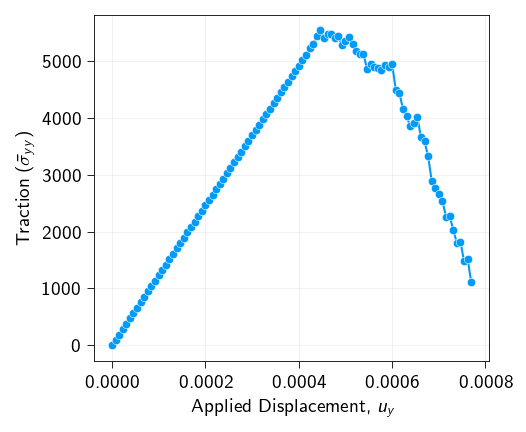

In [ ]:
plt.figure(figsize=(3.4, 3))
plt.plot(displacements, tractions, marker="o", linestyle="-")
plt.xlabel(r"Applied Displacement, $u_y$")
plt.ylabel(r"Traction ($\bar{\sigma}_{yy}$)")
plt.grid(True)
plt.show()

## Visualization

We use PyVista to render the deformed 3D mesh, warped by the final displacement field (amplified for visibility). The $\sigma_{xy}$ shear stress component is shown as a scalar field on the deformed geometry, highlighting the stress concentration near the crack front.

In [ ]:
# [collapse: code] Function for PyVista Visualization after simulation

cells = np.hstack([np.full((mesh.elements.shape[0], 1), 8), mesh.elements]).flatten()
cell_types = np.full(mesh.elements.shape[0], pv.CellType.HEXAHEDRON)
grid = pv.UnstructuredGrid(cells, cell_types, np.array(mesh.coords, dtype=np.float64))

u_current = all_u[-1]
grid.point_data["displacement"] = u_current
grid.points = np.array(mesh.coords + u_current, dtype=np.float64)

grad_u = bulk_op.grad(u_current.reshape(-1, n_dofs_per_node))
strains = compute_strain(grad_u)
stresses = compute_stress(strains, mu, lmbda)
grid.cell_data["stresses"] = np.mean(stresses, axis=1)[..., 0, 1]
grid = grid.warp_by_vector("displacement", factor=4.0)
plotter = pv.Plotter()
plotter.add_mesh(
    grid, show_edges=True, scalars="displacement", component=1, cmap="managua"
)
plotter.show()

![Deformed shape of the 3D bar](../assets/images/cohesive_fracture.gif)